In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings("ignore")


In [2]:
df = pd.read_csv("../data/indian_liver_patient.csv")
df.head()


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [3]:
print(df.shape)
print(df.info())

(583, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB
None


In [4]:
df =  df.rename(columns={'Dataset': 'target'})
df.columns
df['target'].value_counts()

target
1    416
2    167
Name: count, dtype: int64

In [5]:
df['target'].unique()

array([1, 2])

In [6]:
df.describe()

,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,target
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064,1.286449
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


In [7]:
for col in df.columns:
    print(f"{col} contains {df[col].isnull().sum()} values .")

Age contains 0 values .
Gender contains 0 values .
Total_Bilirubin contains 0 values .
Direct_Bilirubin contains 0 values .
Alkaline_Phosphotase contains 0 values .
Alamine_Aminotransferase contains 0 values .
Aspartate_Aminotransferase contains 0 values .
Total_Protiens contains 0 values .
Albumin contains 0 values .
Albumin_and_Globulin_Ratio contains 4 values .
target contains 0 values .


In [8]:
df['Albumin_and_Globulin_Ratio'].fillna(df['Albumin_and_Globulin_Ratio'].mean(),inplace=True)


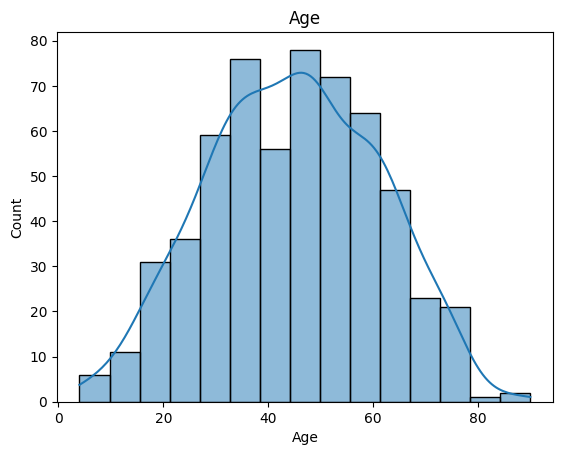

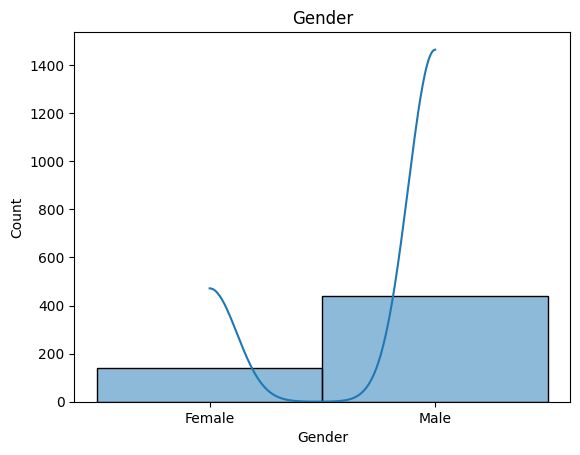

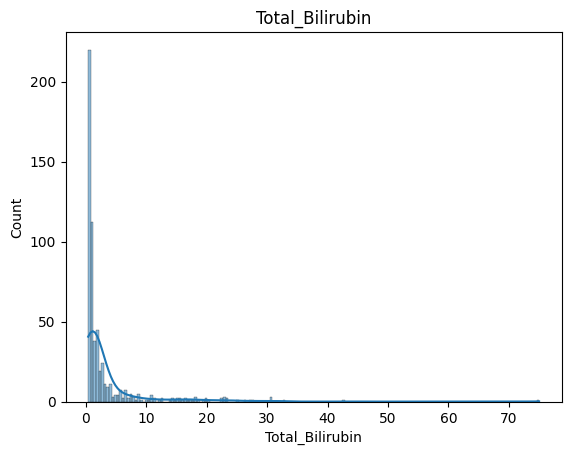

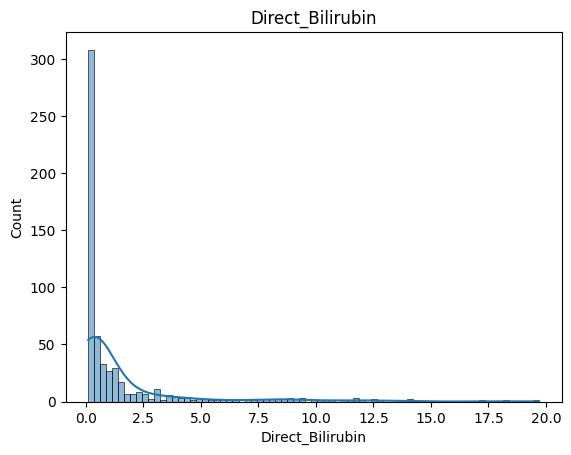

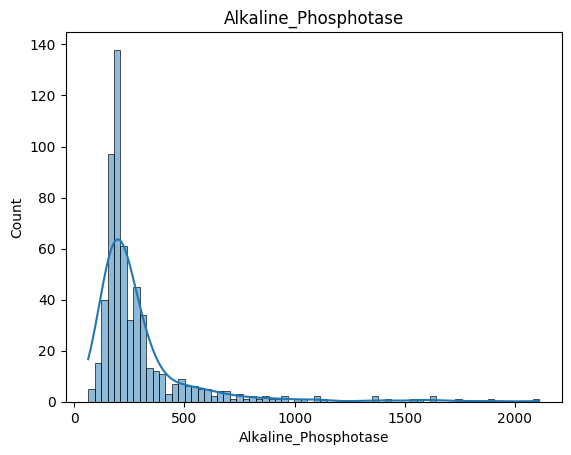

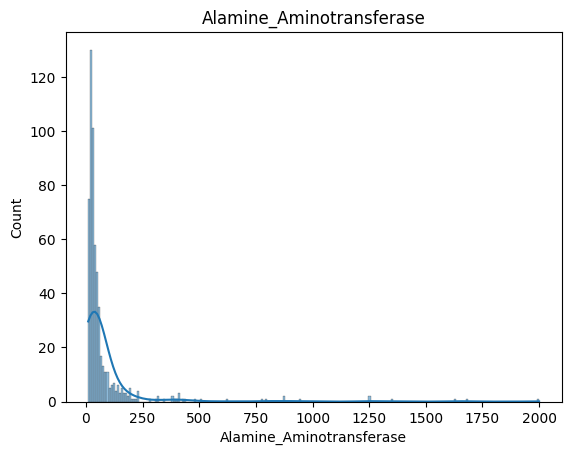

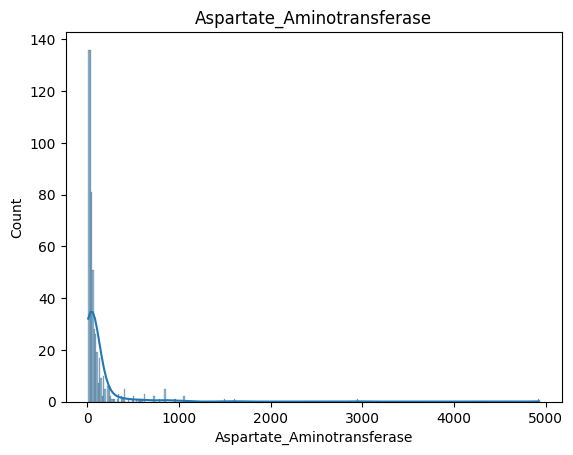

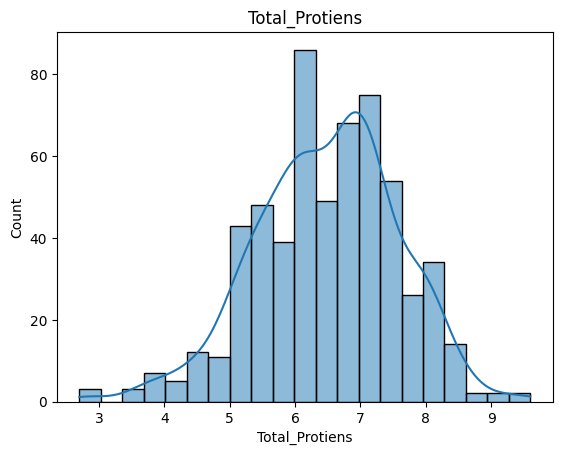

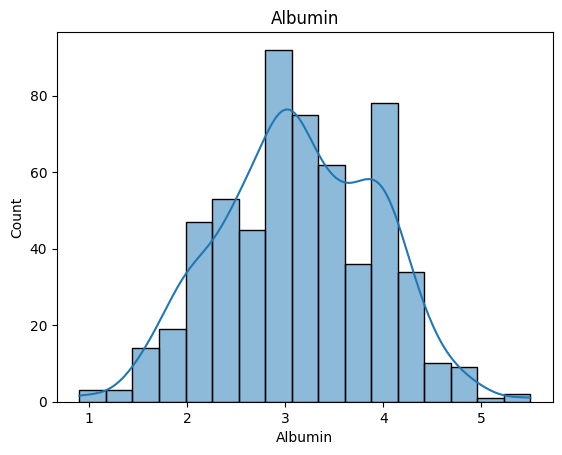

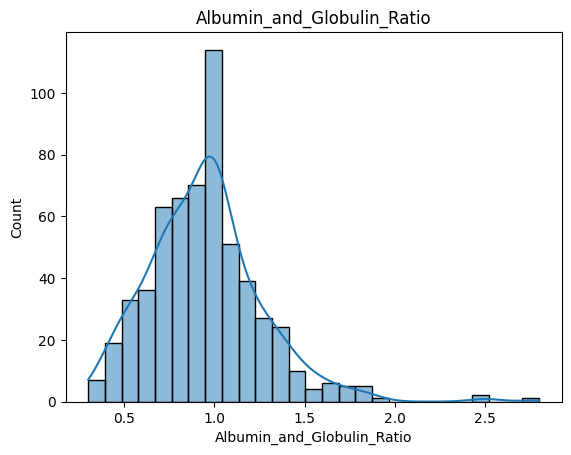

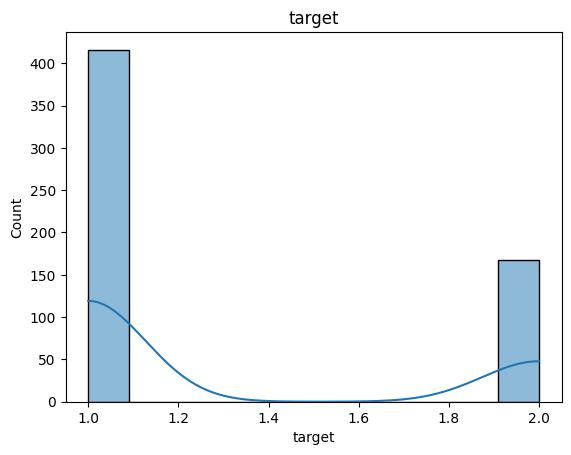

In [9]:
for col in df.columns:
    sns.histplot(df[col] ,kde = True)
    plt.title(col)
    plt.show()


In [49]:
df.skew(numeric_only=True)

Age                           0.034939
Gender                        1.084995
Total_Bilirubin               0.643705
Direct_Bilirubin              0.382132
Alkaline_Phosphotase          0.433260
Alamine_Aminotransferase     -0.046003
Aspartate_Aminotransferase   -0.027402
Total_Protiens               -0.099193
Albumin                      -0.058885
Albumin_and_Globulin_Ratio   -0.773488
target                        0.551023
dtype: float64

Applying log transformation to remove skewness in data 

In [48]:
for col in ['Total_Bilirubin','Direct_Bilirubin','Alkaline_Phosphotase','Alamine_Aminotransferase','Aspartate_Aminotransferase' ,'Albumin_and_Globulin_Ratio']:
    df[col] = np.log1p(df[col])

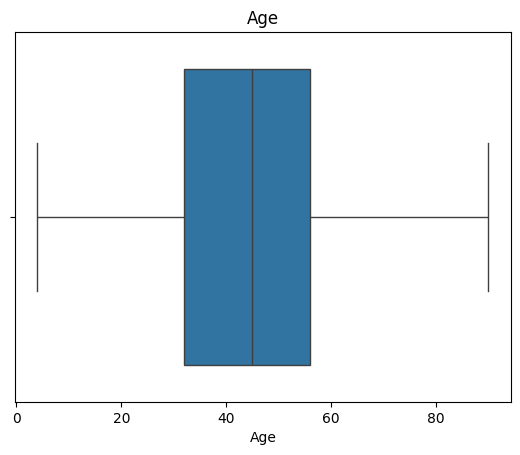

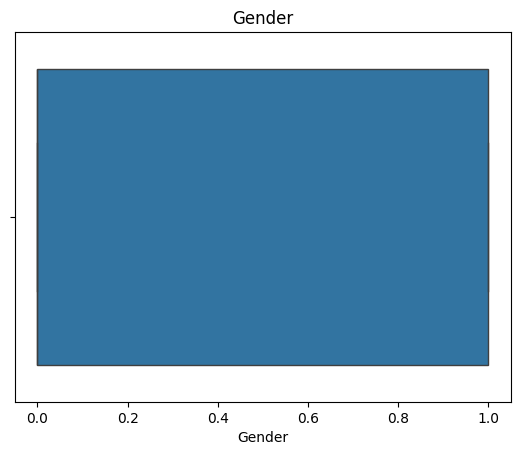

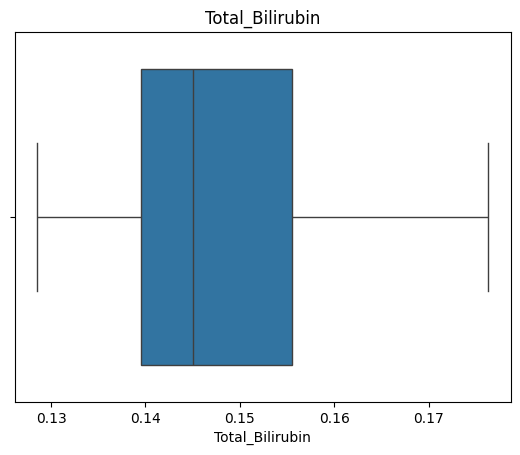

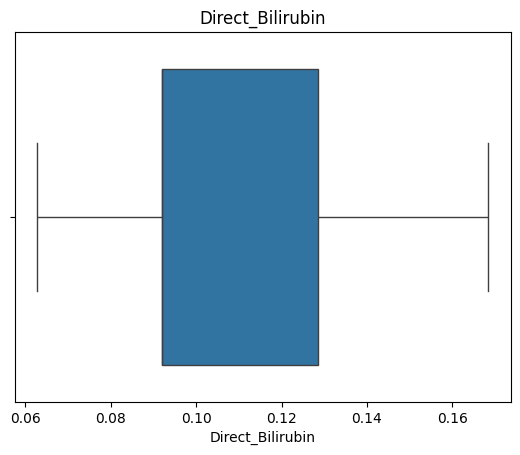

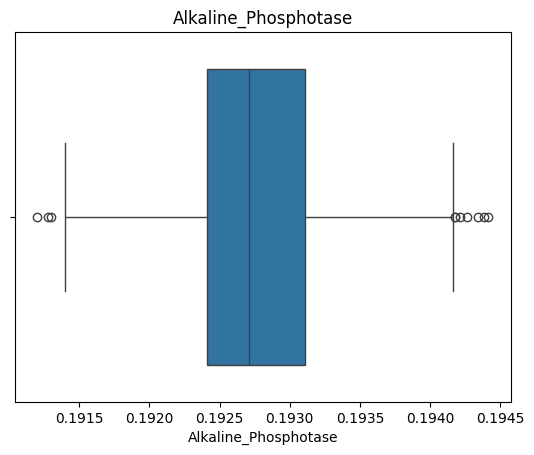

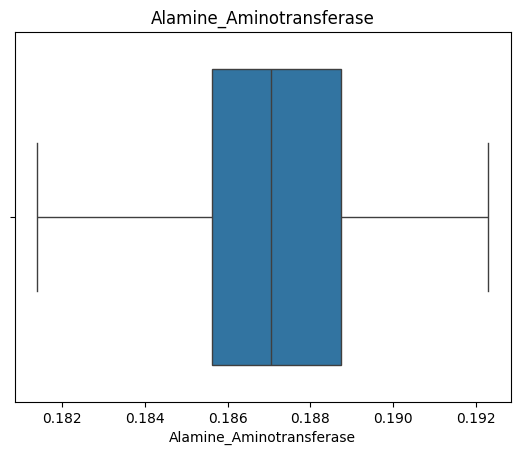

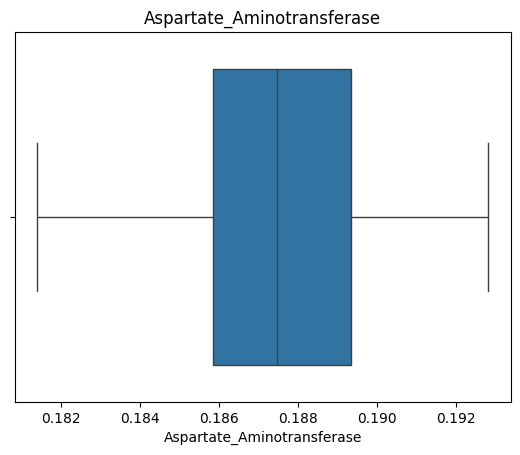

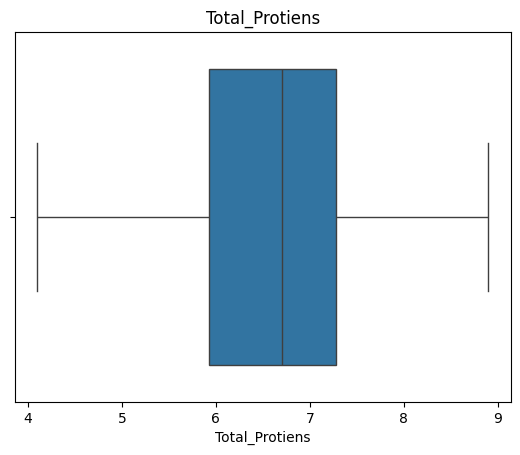

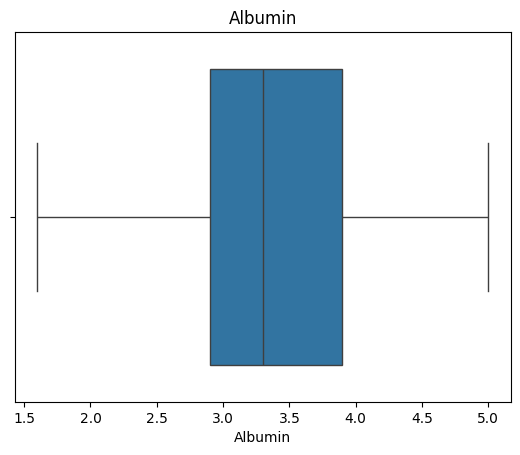

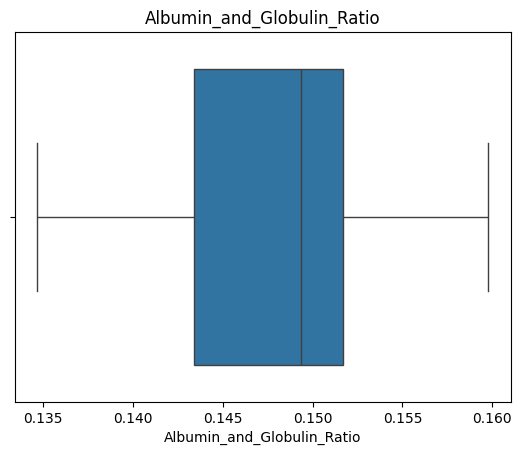

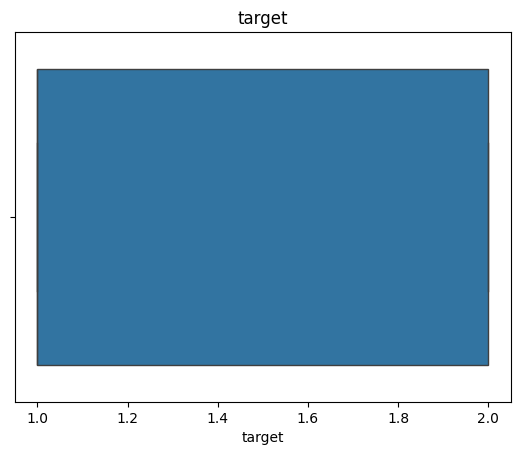

In [52]:

for col in df.select_dtypes(include="number").columns:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [51]:
for col in df.select_dtypes(include="number").columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

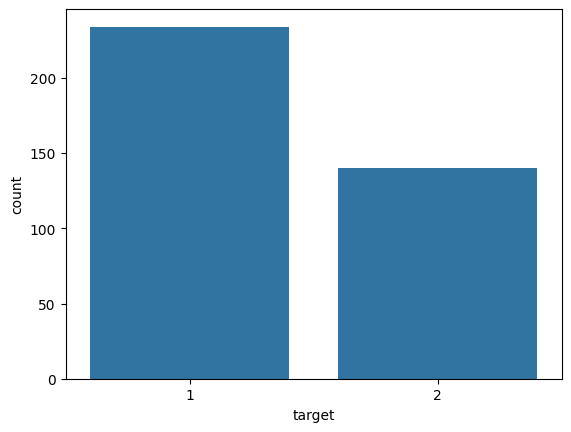

target
1    62.566845
2    37.433155
Name: proportion, dtype: float64

In [53]:
sns.countplot(x = df['target'])
plt.show()
df["target"].value_counts(normalize=True) * 100

In [54]:
df['Gender'] = df['Gender'].map({'Male': 0 ,'Female': 1})

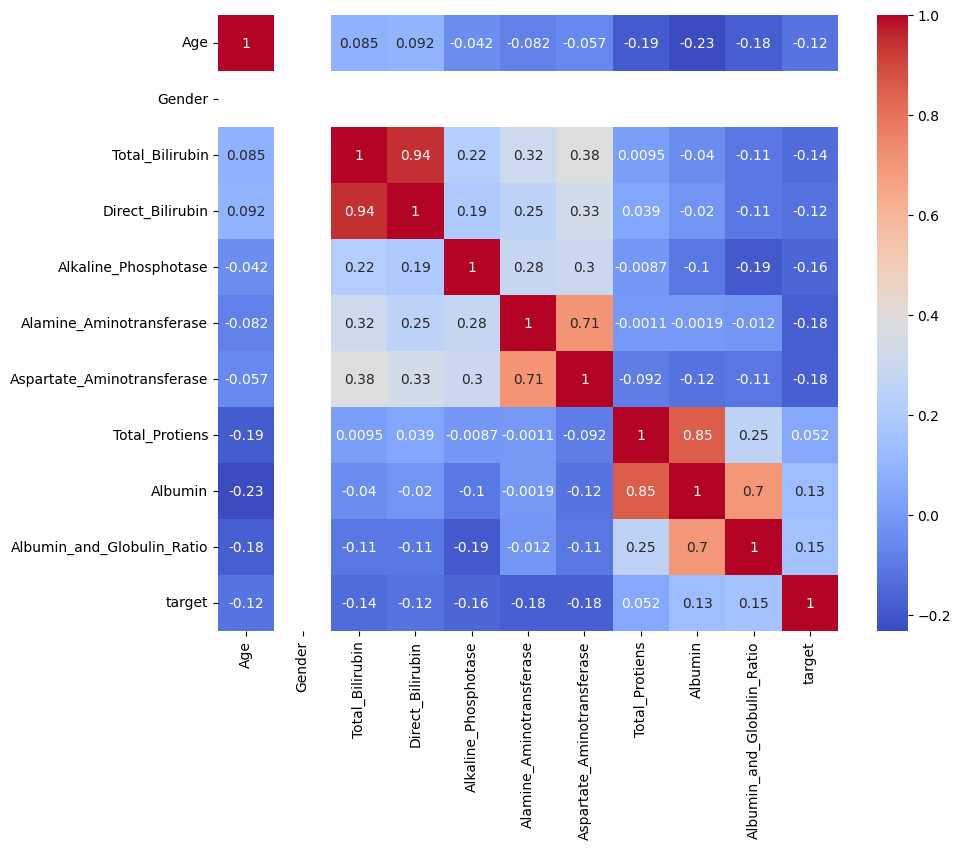

In [55]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [56]:
from sklearn.model_selection import train_test_split , RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [57]:
X = df.drop(columns=['target'])
y = df['target']

In [58]:
X_train,X_test,y_train,y_test= train_test_split(X,y, test_size=0.2,stratify =y)


In [83]:
rf_pipeline = Pipeline([
    ("scaler" , StandardScaler()),
    ("RandomForestClassifier",RandomForestClassifier(random_state = 42))
])
rf_pipeline.fit(X_train,y_train)


,steps,"[('scaler', ...), ('RandomForestClassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [84]:
y_pred_rf = rf_pipeline.predict(X_test)


In [85]:
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report
accuracy_score(y_test,y_pred_rf)

0.6266666666666667

In [88]:
lr_pipeline = Pipeline([
    ('scaler' , StandardScaler()),('logistic regression' ,(LogisticRegression(max_iter=1000, class_weight='balanced')))
]

)
lr_pipeline.fit(X_train, y_train)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [87]:
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_lr = (y_pred_lr >= 0.5).astype(int)
print(accuracy_score(y_test,y_pred_lr))
print(confusion_matrix(y_test,y_pred_lr))
print("\n")
print(classification_report(y_test,y_pred_lr))

NotFittedError: Pipeline is not fitted yet.